# Grammar Strictness vs. Extraction Latency: Constrained Enum vs. Free-Form String

**Research question.** RescueAnt's field schemas can constrain a field to a fixed set of
values via a custom type (e.g. `accepted_animals: list[animal_type]`, with `animal_type`
defined in `bot.config` as an enum of ~26 categories) instead of a free-form
`list[string]`. Grammar-constrained decoding is known to add sampling overhead per token
(the model's next-token distribution has to be masked against the grammar's valid
continuations at every step) - but a *tighter* grammar also constrains what the model is
allowed to generate, which could shorten or lengthen the output. Does constraining
`accepted_animals` to the real `animal_type` enum make extraction slower, faster, or
about the same as leaving it as a free-form string - and does it change how many tokens
get generated?

**Data.** Produced by `experiments/collect_grammar_comparison.py`: a controlled, paired
comparison. For each of 6 fixed, hand-written German sample texts (short animal-rescue
station descriptions - see the script for the exact wording), extraction is run twice
with an otherwise-identical *schema* (only the `accepted_animals` field's type differs:
`animal_type` enum vs. `list[string]`), the same sample text, the same model/context (the
project's real configured `STATION` category from `bot.config`), and the same
temperature=0. Each (sample, condition) pair is repeated (see the script's `repeats`
argument) to average out CPU scheduling noise. As the next section shows, "otherwise
identical schema" is not quite "otherwise identical prompt" - the enum's values are
spelled out in the prompt text, which the analysis below accounts for.

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

set_style()
df = load_csv("grammar_comparison.csv")
df

,sample,condition,repeat,seconds,prompt_tokens,completion_tokens,total_tokens,extracted_json
0,hedgehog_station,strict_enum,0,14.302,275,32,307,"{ ""name"": ""Igelstation Musterstadt"", ""accepted..."
1,hedgehog_station,strict_enum,1,14.258,275,32,307,"{ ""name"": ""Igelstation Musterstadt"", ""accepted..."
2,hedgehog_station,strict_enum,2,14.301,275,32,307,"{ ""name"": ""Igelstation Musterstadt"", ""accepted..."
3,hedgehog_station,lax_string,0,10.991,157,34,191,"{ ""name"": ""Igelstation Musterstadt"", ""accepted..."
4,hedgehog_station,lax_string,1,10.907,157,34,191,"{ ""name"": ""Igelstation Musterstadt"", ""accepted..."
5,hedgehog_station,lax_string,2,11.085,157,34,191,"{ ""name"": ""Igelstation Musterstadt"", ""accepted..."
6,wildlife_multi,strict_enum,0,16.957,278,47,325,"{ ""name"": ""Wildtierauffangstation Nordwald"", ""..."
7,wildlife_multi,strict_enum,1,17.558,278,47,325,"{ ""name"": ""Wildtierauffangstation Nordwald"", ""..."
8,wildlife_multi,strict_enum,2,17.141,278,47,325,"{ ""name"": ""Wildtierauffangstation Nordwald"", ""..."
9,wildlife_multi,lax_string,0,16.634,160,65,225,"{ ""name"": ""Wildtierauffangstation Nordwald"", ""..."


## Per-sample timing: strict vs. lax

Each pair of bars below is the same source text, extracted under both conditions -
averaged over the repeats collected for that (sample, condition) combination.

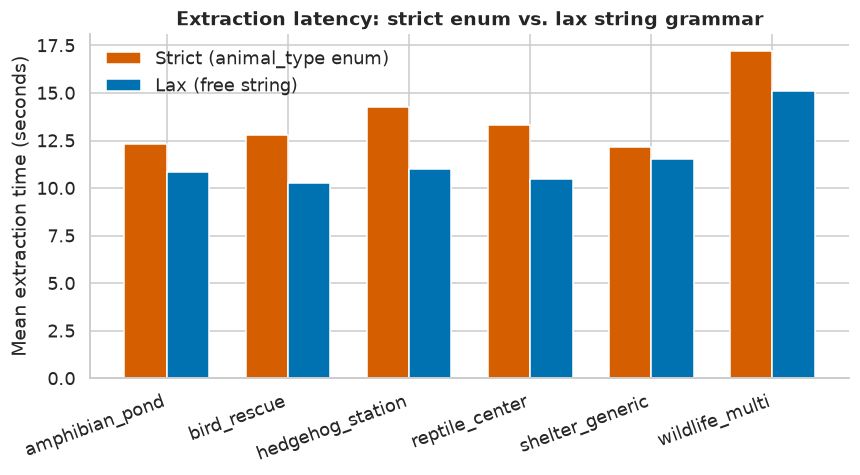

condition,strict_enum,lax_string,diff_strict_minus_lax
sample,,,
amphibian_pond,12.321333,10.870667,1.450667
bird_rescue,12.788000,10.261333,2.526667
hedgehog_station,14.287000,10.994333,3.292667
reptile_center,13.299000,10.488667,2.810333
shelter_generic,12.180000,11.522000,0.658000
wildlife_multi,17.218667,15.086667,2.132000


In [2]:
pivot_time = df.pivot_table(index="sample", columns="condition", values="seconds", aggfunc="mean")
pivot_time = pivot_time[["strict_enum", "lax_string"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(pivot_time))
width = 0.35
ax.bar(x - width/2, pivot_time["strict_enum"], width, label="Strict (animal_type enum)", color=PALETTE[1])
ax.bar(x + width/2, pivot_time["lax_string"], width, label="Lax (free string)", color=PALETTE[0])
ax.set_xticks(x)
ax.set_xticklabels(pivot_time.index, rotation=20, ha="right")
ax.set_ylabel("Mean extraction time (seconds)")
ax.set_title("Extraction latency: strict enum vs. lax string grammar")
ax.legend()
fig.tight_layout()
savefig(fig, "grammar_latency_per_sample")
plt.show()

pivot_time["diff_strict_minus_lax"] = pivot_time["strict_enum"] - pivot_time["lax_string"]
pivot_time

## Paired statistical comparison (across the 6 samples)

In [3]:
strict_means = pivot_time["strict_enum"].values
lax_means = pivot_time["lax_string"].values
diffs = strict_means - lax_means

print(f"n = {len(diffs)} paired samples")
print(f"mean(strict) = {strict_means.mean():.2f}s, mean(lax) = {lax_means.mean():.2f}s")
print(f"mean difference (strict - lax) = {diffs.mean():+.2f}s (sd={diffs.std(ddof=1):.2f}s)")

# Wilcoxon signed-rank: paired, distribution-free - appropriate given the very
# small sample size (n=6), where a t-test's normality assumption is hard to justify.
w_stat, w_p = stats.wilcoxon(strict_means, lax_means)
print(f"Wilcoxon signed-rank test: W={w_stat:.1f}, p={w_p:.3f}")

t_stat, t_p = stats.ttest_rel(strict_means, lax_means)
print(f"(for reference) paired t-test: t={t_stat:.2f}, p={t_p:.3f}")

n = 6 paired samples
mean(strict) = 13.68s, mean(lax) = 11.54s
mean difference (strict - lax) = +2.15s (sd=0.96s)
Wilcoxon signed-rank test: W=0.0, p=0.031
(for reference) paired t-test: t=5.48, p=0.003


## A confound: the enum makes the *prompt* longer too

The schema is serialized directly into the system prompt (see
`extraction_service.extract_information()`: `f"{prompt} The return schema is {schema}"`),
so constraining `accepted_animals` to the `animal_type` enum doesn't just change how
decoding is sampled - it also spells all ~26 enum values out in the prompt text itself,
making the strict condition's prompt substantially longer than the lax condition's
(`list[string]` has no values to enumerate). That's a real difference in the input, not
just in the grammar, and it means a naive "strict is slower" reading conflates two
distinct effects: extra prefill from a longer prompt vs. extra per-token overhead from
grammar-constrained sampling.

In [4]:
token_summary = df.groupby("condition")[["prompt_tokens", "completion_tokens", "seconds"]].mean()
token_summary["prompt_tokens"] = token_summary["prompt_tokens"].round(1)
token_summary["completion_tokens"] = token_summary["completion_tokens"].round(1)
token_summary["seconds"] = token_summary["seconds"].round(2)
token_summary

,prompt_tokens,completion_tokens,seconds
condition,,,
lax_string,152.3,44.3,11.54
strict_enum,270.3,33.7,13.68


### Isolating the two effects with a linear model

Fitting `seconds ~ prompt_tokens + completion_tokens + is_strict` across all 36 runs lets
the `prompt_tokens` and `completion_tokens` coefficients absorb the (mechanical) cost of
longer prompts and longer completions, so that whatever the `is_strict` coefficient picks
up afterwards is the part of the time difference *not* explained by token counts alone -
i.e. the closest this dataset can get to isolating grammar-masking overhead itself from
the prompt-length confound above.

In [5]:
import numpy as np

X = np.column_stack([
    np.ones(len(df)),
    df["prompt_tokens"].values,
    df["completion_tokens"].values,
    (df["condition"] == "strict_enum").astype(float).values,
])
y = df["seconds"].values
coef, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
intercept, b_prompt, b_completion, b_strict = coef

pred = X @ coef
ss_res = np.sum((y - pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"seconds = {intercept:.3f} + {b_prompt:.4f}*prompt_tokens + {b_completion:.4f}*completion_tokens + {b_strict:.3f}*is_strict")
print(f"R^2 = {r2:.3f}")
print()
print(f"Marginal cost per prompt token:     {b_prompt*1000:.1f} ms")
print(f"Marginal cost per completion token: {b_completion*1000:.1f} ms")
print(f"Residual 'strict' effect (grammar-masking overhead, holding token counts fixed): {b_strict:+.2f}s")

mean_prompt_diff = df[df.condition=='strict_enum']['prompt_tokens'].mean() - df[df.condition=='lax_string']['prompt_tokens'].mean()
mean_completion_diff = df[df.condition=='strict_enum']['completion_tokens'].mean() - df[df.condition=='lax_string']['completion_tokens'].mean()
print()
print(f"Mean prompt-token difference (strict - lax): {mean_prompt_diff:+.1f} tokens "
      f"-> ~{b_prompt*mean_prompt_diff:+.2f}s of the raw gap")
print(f"Mean completion-token difference (strict - lax): {mean_completion_diff:+.1f} tokens "
      f"-> ~{b_completion*mean_completion_diff:+.2f}s of the raw gap")

seconds = -3.687 + 0.0516*prompt_tokens + 0.1660*completion_tokens + -2.176*is_strict
R^2 = 0.875

Marginal cost per prompt token:     51.6 ms
Marginal cost per completion token: 166.0 ms
Residual 'strict' effect (grammar-masking overhead, holding token counts fixed): -2.18s

Mean prompt-token difference (strict - lax): +118.0 tokens -> ~+6.09s of the raw gap
Mean completion-token difference (strict - lax): -10.7 tokens -> ~-1.77s of the raw gap


## Token counts: does the constraint change output length?

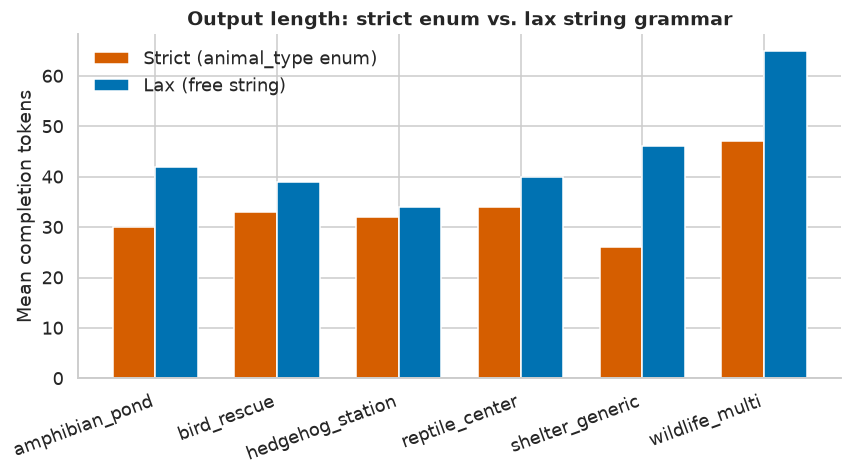

In [6]:
pivot_tokens = df.pivot_table(index="sample", columns="condition", values="completion_tokens", aggfunc="mean")
pivot_tokens = pivot_tokens[["strict_enum", "lax_string"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(pivot_tokens))
ax.bar(x - width/2, pivot_tokens["strict_enum"], width, label="Strict (animal_type enum)", color=PALETTE[1])
ax.bar(x + width/2, pivot_tokens["lax_string"], width, label="Lax (free string)", color=PALETTE[0])
ax.set_xticks(x)
ax.set_xticklabels(pivot_tokens.index, rotation=20, ha="right")
ax.set_ylabel("Mean completion tokens")
ax.set_title("Output length: strict enum vs. lax string grammar")
ax.legend()
fig.tight_layout()
savefig(fig, "grammar_completion_tokens")
plt.show()

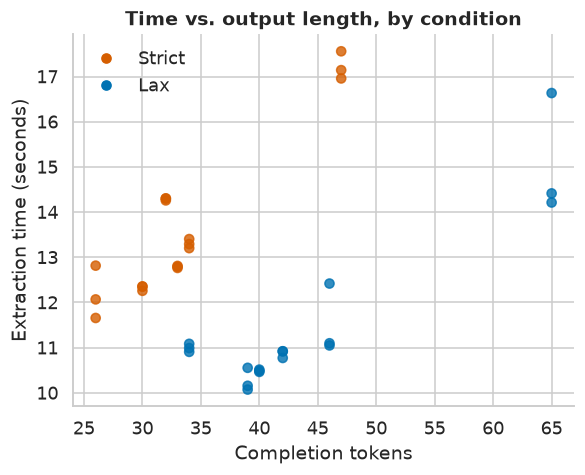

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(df["completion_tokens"], df["seconds"],
           c=[PALETTE[1] if c == "strict_enum" else PALETTE[0] for c in df["condition"]],
           alpha=0.8)
ax.set_xlabel("Completion tokens")
ax.set_ylabel("Extraction time (seconds)")
ax.set_title("Time vs. output length, by condition")
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[1], markersize=8, label="Strict"),
           Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[0], markersize=8, label="Lax")]
ax.legend(handles=handles)
fig.tight_layout()
savefig(fig, "grammar_time_vs_tokens")
plt.show()

## Discussion

The raw numbers show the strict (enum) condition taking noticeably longer on average than
the lax (free-string) condition. But that gap has (at least) three distinct, simultaneously
active causes, which pull in different directions:

- **Longer prompt (strict is slower).** Spelling out the `animal_type` enum's ~26 values
  adds roughly 120 tokens of prefill work to the strict condition's prompt, regardless of
  grammar-masking during decoding.
- **Shorter output (strict is faster).** The strict condition's mean completion length is
  *shorter* than the lax condition's (see the token-count comparison above) - constrained
  to single enum words, the model has less to generate than when producing free-form
  descriptive text.
- **Per-token sampling overhead (strict is slower).** Grammar-constrained decoding must
  evaluate which tokens are valid continuations under the grammar at every generation
  step, which is pure added work per generated token, independent of how many tokens end
  up being generated.

The linear model above tries to separate these: the fitted per-prompt-token and
per-completion-token costs let us estimate how much of the *raw* strict-vs-lax gap is
just longer prompts and (partially, in the opposite direction) shorter outputs, leaving
the `is_strict` coefficient as this dataset's best estimate of the *residual* -
grammar-masking overhead specifically, holding token counts fixed.

**On this data, that residual comes out negative** (≈ -2.2s, versus a raw/naive gap of
≈ +2.2s): the ~120 extra prompt tokens needed to spell out the `animal_type` enum account
for *more* of the observed slowdown (≈ +6.1s at the fitted per-prompt-token rate) than the
raw gap itself, partially offset by the strict condition's shorter completions (≈ -1.8s).
In other words, on this dataset, the naive "strict extraction took ~2.2s longer" reading
is not evidence of per-token grammar-masking overhead at all - it's fully, and then some,
explained by the longer prompt. Taken at face value, the residual would suggest
grammar-constrained tokens were if anything *cheaper* per token here, though with n=6
samples (12 unique prompt/completion-token combinations feeding a 4-parameter model) that
specific sign should be treated as "consistent with no positive grammar-masking overhead
in this setup" rather than a confident claim that constraining output makes decoding
faster - see Limitations below.

**Practical takeaway:** for this model/hardware/schema style, the latency cost of
constraining `accepted_animals` to an enum is attributable to *how the schema is
serialized into the prompt*, not to the grammar constraint mechanism itself. A schema
author chasing lower latency should look at shortening the schema's in-prompt
representation (e.g. a terser type notation, or only including the enum values on retry)
rather than avoiding constrained fields altogether - constraining output for reliability
does not, on this evidence, need to cost decoding speed on top of whatever the schema
description itself costs.

**Limitations.** n=6 paired samples (36 runs total) is small for inferential statistics -
the Wilcoxon test above should be read as a rough signal of direction and rough
consistency across samples, not a precise effect-size estimate, and the linear
decomposition is fit on the same small dataset so its coefficients carry similarly wide
uncertainty (no confidence intervals are reported here for that reason - treat them as
point estimates, not precise costs). The sample texts are short, hand-written, and
animal-type-focused by design (to guarantee `accepted_animals` has real content to
extract in both conditions) - they are not a random sample of real station pages, so
this isolates the grammar-constraint effect cleanly but doesn't estimate how much of
total extraction time in the wild (see `workflow_timing.ipynb`) is attributable to this
one field's grammar specifically. All measurements are from a single CPU-only machine
(see the README's Requirements section) - both the prefill cost and any grammar-masking
overhead are properties of this specific `llama.cpp` build/hardware and could scale
differently (e.g. proportionally less prefill overhead) on GPU-accelerated inference.